In [77]:
import nba_api
from nba_api.stats.endpoints import leaguedashplayerstats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb



In [ ]:
player_stats = pd.read_csv("player_stats.csv")
nba_salaires = pd.read_csv("nba_salaries.csv")
print("Stats shape:", player_stats.shape)
print("Salaries shape:", nba_salaires.shape)

print("\n")
print("Stats columns:", player_stats.columns)
print("Salaries columns:", nba_salaires.columns)

player_stats.rename(columns={"season": "Season", 'PLAYER_NAME' : 'Player'}, inplace=True)
print("\n")
print("Stats columns after rename:", player_stats.columns)

df = pd.merge(player_stats, nba_salaires, on=["Player", "Season"], how="inner")
print("\n")
print("Merged DataFrame shape:", df.shape)
print("Merged DataFrame columns:", df.columns)



Stats shape: (12798, 27)
Salaries shape: (12386, 3)


Stats columns: Index(['PLAYER_ID', 'PLAYER_NAME', 'AGE', 'season', 'GP', 'MIN', 'FGM', 'FGA',
       'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB',
       'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS',
       'DD2', 'TD3'],
      dtype='str')
Salaries columns: Index(['Player', 'Salary', 'Season'], dtype='str')


Stats columns after rename: Index(['PLAYER_ID', 'Player', 'AGE', 'Season', 'GP', 'MIN', 'FGM', 'FGA',
       'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB',
       'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS',
       'DD2', 'TD3'],
      dtype='str')


Merged DataFrame shape: (8947, 28)
Merged DataFrame columns: Index(['PLAYER_ID', 'Player', 'AGE', 'Season', 'GP', 'MIN', 'FGM', 'FGA',
       'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB',
       'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS',
 

np.int64(3)

<Figure size 1500x700 with 0 Axes>

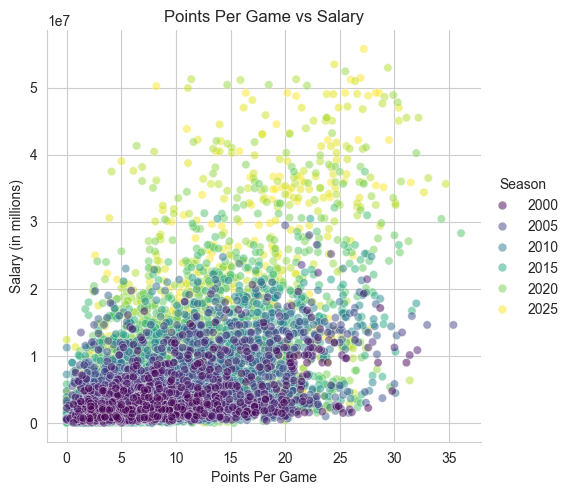

count    8.947000e+03
mean     6.332322e+06
std      7.757501e+06
min      4.533000e+03
25%      1.500000e+06
50%      3.375360e+06
75%      8.105488e+06
max      5.576122e+07
Name: Salary, dtype: float64


In [ ]:
#EDA
# points per game vs salary
sns.set_style("whitegrid")
plt.figure(figsize=(15, 7))
sns.relplot(data=df, x="PTS", y="Salary", alpha=0.5, hue="Season", palette="viridis")
plt.title("Points Per Game vs Salary")
plt.xlabel("Points Per Game")
plt.ylabel("Salary (in 10 millions)")
plt.show()
print(df['Salary'].describe())

              0%        25%        50%        75%        100%
Season                                                       
2000    301000.0  1976000.0  3000000.0  5301000.0  17142000.0
2001     24000.0  1040250.0  2250000.0  5000000.0  19600000.0
2002    237000.0   920750.0  2403000.0  4700500.0  22400000.0
2003    512000.0  1723000.0  3600000.0  6600000.0  25200000.0
2004    587000.0  2386500.0  4614000.0  7646000.0  28000000.0


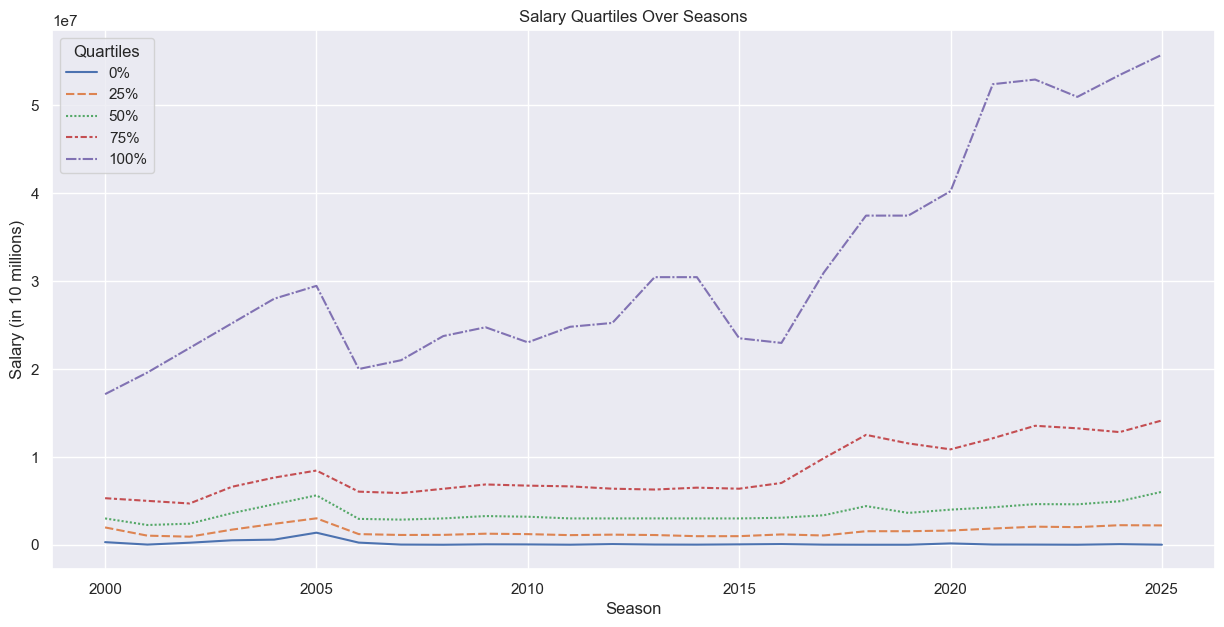

In [ ]:
# salary quartiles (0%, 25%, 50%, 75%, 100%) over seasons line plot
quartiles_by_season = (
    df.groupby("Season")["Salary"]
    .quantile([0, 0.25, 0.5, 0.75, 1.0])
    .unstack()
)

quartiles_by_season.columns = ["0%", "25%", "50%", "75%", "100%"]

print(quartiles_by_season.head())

plt.figure(figsize=(15, 7))
sns.lineplot(data=quartiles_by_season)
plt.title("Salary Quartiles Over Seasons")
plt.xlabel("Season")
plt.ylabel("Salary (in 10 millions)")
plt.legend(title="Quartiles")
plt.show()


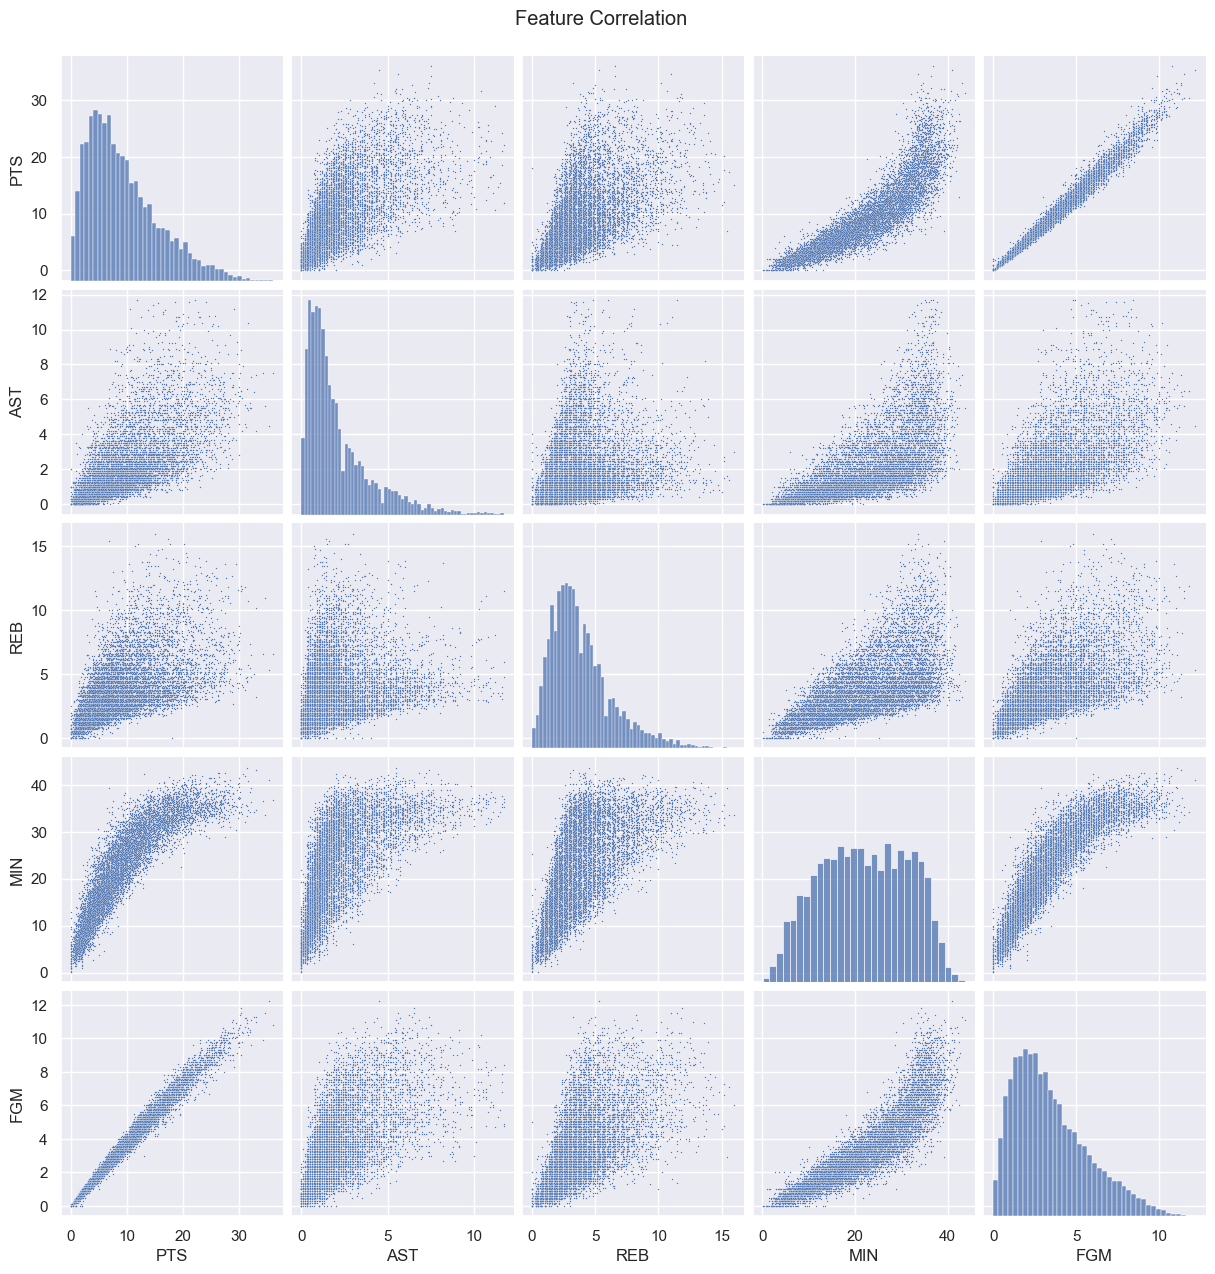

In [60]:
# correlation heatmap

corr = pd.DataFrame({
	"PTS": df["PTS"],
	"AST": df["AST"],
	"REB": df["REB"],
	"MIN": df["MIN"],
	"FGM": df["FGM"],
})

sns.pairplot(corr, plot_kws={"s": 1})
plt.suptitle("Feature Correlation", y=1.02)
plt.show()


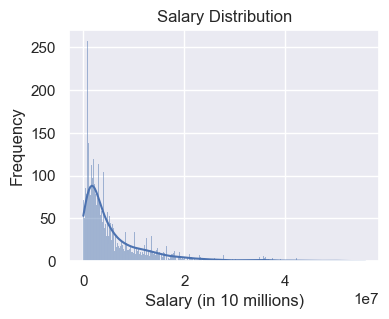

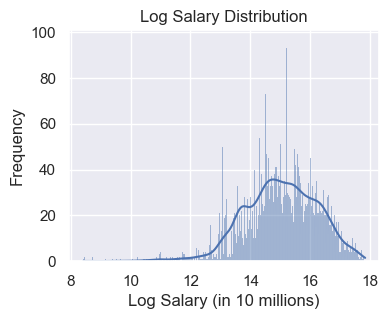

In [61]:
#salary histogram and log salary histogram
plt.figure(figsize=(4, 3))
sns.histplot(df["Salary"], bins=750, kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary (in 10 millions)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(4, 3))
sns.histplot(np.log1p(df["Salary"]), bins=750, kde=True)
plt.title("Log Salary Distribution")
plt.xlabel("Log Salary (in 10 millions)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#machine learning models

#Linear Regression
df['Salary_M'] = df['Salary'] / 1e7
print(df.columns)
y = df["Salary_M"]
X = df.drop(columns=["Salary", "Salary_M", "Player", 'PLAYER_ID'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")


Index(['PLAYER_ID', 'Player', 'AGE', 'Season', 'GP', 'MIN', 'FGM', 'FGA',
       'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB',
       'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS',
       'DD2', 'TD3', 'Salary', 'Salary_M'],
      dtype='str')
Mean Squared Error: 0.30
R^2 Score: 0.52


In [76]:
#random forest
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor())
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

random_forest_param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [None, 10, 20],
    "regressor__min_samples_split": [2, 5],
    "regressor__min_samples_leaf": [1, 2]
}
grid_search = GridSearchCV(model, random_forest_param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Best Random Forest Mean Squared Error: {mse:.2f}")
print(f"Best Random Forest R^2 Score: {r2:.2f}")




Mean Squared Error: 0.21
R^2 Score: 0.66
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END regressor__max_depth=None, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   7.3s
[CV] END regressor__max_depth=None, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   7.3s
[CV] END regressor__max_depth=None, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   7.3s
[CV] END regressor__max_depth=None, regressor__min_samples_leaf=1, regressor__min_samples_split=5, regressor__n_estimators=100; total time=   6.3s
[CV] END regressor__max_depth=None, regressor__min_samples_leaf=1, regressor__min_samples_split=5, regressor__n_estimators=100; total time=   6.3s
[CV] END regressor__max_depth=None, regressor__min_samples_leaf=1, regressor__min_samples_split=5, regressor__n_estimators=100; total time=   6.5s
[CV] END regress

In [79]:
# xgboost
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", xgb.XGBRegressor())
])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")
xgboost_param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [3, 6, 10],
    "regressor__learning_rate": [0.01, 0.1, 0.2],
    "regressor__subsample": [0.8, 1.0],
    "regressor__colsample_bytree": [0.8, 1.0]
}
grid_search = GridSearchCV(model, xgboost_param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
best_xgb_model = grid_search.best_estimator_
y_pred = best_xgb_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Best XGBoost Mean Squared Error: {mse:.2f}")
print(f"Best XGBoost R^2 Score: {r2:.2f}")


Mean Squared Error: 0.22
R^2 Score: 0.66
Fitting 3 folds for each of 72 candidates, totalling 216 fits
[CV] END regressor__colsample_bytree=0.8, regressor__learning_rate=0.01, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.8; total time=   0.2s
[CV] END regressor__colsample_bytree=0.8, regressor__learning_rate=0.01, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.8; total time=   0.2s
[CV] END regressor__colsample_bytree=0.8, regressor__learning_rate=0.01, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=1.0; total time=   0.2s
[CV] END regressor__colsample_bytree=0.8, regressor__learning_rate=0.01, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=1.0; total time=   0.2s
[CV] END regressor__colsample_bytree=0.8, regressor__learning_rate=0.01, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=1.0; total time=   0.2s
[CV] END regressor__colsample_bytree=0.8, 

In [83]:
# most important features from xgboost
xgb_model = best_xgb_model.named_steps["regressor"]
feature_importances = xgb_model.feature_importances_
# Since there are no categorical features, use only numeric_features
feature_names = numeric_features.tolist()
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)
print(feature_importance_df.head(20))

       Feature  Importance
21         PTS    0.409381
1       Season    0.091331
0          AGE    0.079225
4          FGM    0.043261
14        DREB    0.032735
11         FTA    0.029313
10         FTM    0.025610
19         TOV    0.023887
15         REB    0.023219
3          MIN    0.021750
16         AST    0.021634
24         TD3    0.021275
18         BLK    0.018953
5          FGA    0.016297
23         DD2    0.014727
22  PLUS_MINUS    0.014483
13        OREB    0.013835
12      FT_PCT    0.013474
6       FG_PCT    0.013120
20          PF    0.013074


In [84]:
# NEXT_SEASON_MODEL: build a forecasting dataset with lagged features and a next-season target
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

model_stats = pd.read_csv("player_stats_model_ready.csv")
salary_history = pd.read_csv("nba_salaries.csv")

forecast_df = model_stats.merge(salary_history, on=["Player", "Season"], how="inner")
forecast_df = forecast_df.sort_values(["PLAYER_ID", "Season"]).reset_index(drop=True)
forecast_df["target_season"] = forecast_df.groupby("PLAYER_ID")["Season"].shift(-1)
forecast_df["next_salary"] = forecast_df.groupby("PLAYER_ID")["Salary"].shift(-1)
forecast_df = forecast_df[forecast_df["target_season"] == forecast_df["Season"] + 1].copy()
forecast_df["target_season"] = forecast_df["target_season"].astype(int)
forecast_df["log_next_salary"] = np.log1p(forecast_df["next_salary"])

feature_columns = [
    column for column in forecast_df.columns
    if column not in {"Player", "PLAYER_ID", "next_salary", "log_next_salary", "target_season"}
]

X_forecast = forecast_df[feature_columns]
y_forecast = forecast_df["log_next_salary"]
target_seasons = sorted(forecast_df["target_season"].unique())
eval_seasons = target_seasons[-6:] if len(target_seasons) >= 6 else target_seasons

print("Forecast rows:", len(forecast_df))
print("Feature count:", len(feature_columns))
print("Target seasons used for evaluation:", eval_seasons)
forecast_df[["Player", "Season", "Salary", "next_salary", "target_season"]].head()


Forecast rows: 6845
Feature count: 85
Target seasons used for evaluation: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,Player,Season,Salary,next_salary,target_season
0,Grant Long,2000,2000000,2200000.0,2001
1,Grant Long,2001,2200000,2400000.0,2002
3,Eric Piatkowski,2000,2000000,3000000.0,2001
4,Eric Piatkowski,2001,3000000,3000000.0,2002
6,Eric Piatkowski,2006,3000000,1178348.0,2007


In [85]:
# NEXT_SEASON_MODEL: compare stronger models with season-based validation and fit the best one
candidate_models = {
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.2, max_iter=20000),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=800,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_depth=6,
        max_iter=500,
        l2_regularization=1.0,
        random_state=42,
    ),
}

if HAS_XGBOOST:
    candidate_models["XGBoost"] = XGBRegressor(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
    )


def evaluate_candidate(name, estimator):
    season_metrics = []
    for season in eval_seasons:
        train_mask = forecast_df["target_season"] < season
        test_mask = forecast_df["target_season"] == season

        if train_mask.sum() < 200 or test_mask.sum() == 0:
            continue

        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ])
        pipeline.fit(X_forecast.loc[train_mask], y_forecast.loc[train_mask])

        pred_log = pipeline.predict(X_forecast.loc[test_mask])
        pred_salary = np.expm1(pred_log)
        actual_salary = forecast_df.loc[test_mask, "next_salary"]

        season_metrics.append({
            "model": name,
            "season": season,
            "rows": int(test_mask.sum()),
            "rmse": float(np.sqrt(mean_squared_error(actual_salary, pred_salary))),
            "mae": float(mean_absolute_error(actual_salary, pred_salary)),
            "r2": float(r2_score(actual_salary, pred_salary)),
        })

    return pd.DataFrame(season_metrics)

all_results = []
for model_name, estimator in candidate_models.items():
    result = evaluate_candidate(model_name, estimator)
    if not result.empty:
        all_results.append(result)

results_df = pd.concat(all_results, ignore_index=True)
summary_df = (
    results_df.groupby("model")[["rmse", "mae", "r2"]]
    .mean()
    .sort_values(["mae", "rmse"], ascending=[True, True])
)

print("Average validation metrics by model:")
display(summary_df)
print("Validation metrics by season:")
display(results_df.sort_values(["season", "mae"]))

best_model_name = summary_df.index[0]
best_estimator = candidate_models[best_model_name]
latest_season = eval_seasons[-1]

final_train_mask = forecast_df["target_season"] < latest_season
final_test_mask = forecast_df["target_season"] == latest_season
best_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", best_estimator),
])
best_pipeline.fit(X_forecast.loc[final_train_mask], y_forecast.loc[final_train_mask])

final_pred_salary = np.expm1(best_pipeline.predict(X_forecast.loc[final_test_mask]))
final_actual_salary = forecast_df.loc[final_test_mask, "next_salary"]

print(f"Best model: {best_model_name}")
print(f"Latest holdout season: {latest_season}")
print(f"Holdout RMSE: {np.sqrt(mean_squared_error(final_actual_salary, final_pred_salary)):,.0f}")
print(f"Holdout MAE: {mean_absolute_error(final_actual_salary, final_pred_salary):,.0f}")
print(f"Holdout R^2: {r2_score(final_actual_salary, final_pred_salary):.3f}")

comparison_df = forecast_df.loc[final_test_mask, ["Player", "Season", "Salary", "next_salary"]].copy()
comparison_df["predicted_next_salary"] = final_pred_salary
comparison_df["absolute_error"] = (comparison_df["next_salary"] - comparison_df["predicted_next_salary"]).abs()
print("Most accurate predictions on the holdout season:")
display(comparison_df.sort_values("absolute_error").head(15))
print("Largest misses on the holdout season:")
display(comparison_df.sort_values("absolute_error", ascending=False).head(15))

importance = permutation_importance(
    best_pipeline,
    X_forecast.loc[final_test_mask],
    y_forecast.loc[final_test_mask],
    n_repeats=10,
    random_state=42,
)
importance_df = pd.DataFrame({
    "feature": X_forecast.columns,
    "importance": importance.importances_mean,
}).sort_values("importance", ascending=False)
print("Top holdout-season feature importances:")
display(importance_df.head(20))


Average validation metrics by model:


,rmse,mae,r2
model,,,
HistGradientBoosting,4.854882e+06,2.963826e+06,0.825294
ExtraTrees,5.023335e+06,2.981825e+06,0.813236
XGBoost,5.000151e+06,3.054674e+06,0.814174
ElasticNet,2.494629e+07,9.280249e+06,-4.182282


Validation metrics by season:


,model,season,rows,rmse,mae,r2
12,HistGradientBoosting,2020,312,4.697805e+06,2.796308e+06,0.753195
18,XGBoost,2020,312,4.851038e+06,2.860221e+06,0.736832
6,ExtraTrees,2020,312,4.833070e+06,2.893598e+06,0.738778
0,ElasticNet,2020,312,1.161124e+07,5.170263e+06,-0.507722
13,HistGradientBoosting,2021,300,6.240431e+06,3.733907e+06,0.733922
19,XGBoost,2021,300,6.518184e+06,3.949507e+06,0.709709
7,ExtraTrees,2021,300,6.473886e+06,4.113738e+06,0.713642
1,ElasticNet,2021,300,1.565420e+07,6.944033e+06,-0.674333
8,ExtraTrees,2022,307,4.812877e+06,2.850929e+06,0.844244
20,XGBoost,2022,307,4.862000e+06,3.009431e+06,0.841048


Best model: HistGradientBoosting
Latest holdout season: 2025
Holdout RMSE: 4,903,098
Holdout MAE: 3,120,095
Holdout R^2: 0.858
Most accurate predictions on the holdout season:


,Player,Season,Salary,next_salary,predicted_next_salary,absolute_error
5032,Garrett Temple,2024,3291427,2087519.0,2.082178e+06,5340.591214
8732,Julian Strawther,2024,2503279,2552520.0,2.559709e+06,7188.676516
7887,Jordan McLaughlin,2024,2491907,2087519.0,2.104149e+06,16629.969783
6532,Kyle Anderson,2024,9493460,8780488.0,8.754536e+06,25951.826365
7939,Jalen Pickett,2024,1758898,1891857.0,1.863356e+06,28501.486470
8864,Kobe Brown,2024,2485066,2533920.0,2.495165e+06,38755.283876
8661,Scoot Henderson,2024,10061236,10259160.0,1.031162e+07,52460.797246
8740,Jabari Walker,2024,1770967,2019699.0,2.074382e+06,54682.811892
8876,Jordan Miller,2024,576415,1050000.0,9.930303e+05,56969.698301
7490,Josh Hart,2024,13345093,18144000.0,1.820792e+07,63919.120356


Largest misses on the holdout season:


,Player,Season,Salary,next_salary,predicted_next_salary,absolute_error
3195,Chris Paul,2024,31715190,10460000.0,3.259591e+07,2.213591e+07
7358,Lauri Markkanen,2024,17772862,42176400.0,2.289066e+07,1.928574e+07
5451,Klay Thompson,2024,44503661,15873016.0,3.467793e+07,1.880491e+07
7442,Isaiah Hartenstein,2024,9519830,30000000.0,1.319485e+07,1.680515e+07
7406,OG Anunoby,2024,19196810,36637932.0,2.090053e+07,1.573740e+07
7623,Miles Bridges,2024,8156673,27173913.0,1.226410e+07,1.490981e+07
7958,Zion Williamson,2024,35015681,36725670.0,5.130409e+07,1.457842e+07
8248,Devin Vassell,2024,6062851,29347826.0,1.497381e+07,1.437401e+07
3747,Kyle Lowry,2024,30564525,2087519.0,1.525384e+07,1.316632e+07
4738,Stephen Curry,2024,53458234,55761216.0,4.382801e+07,1.193321e+07


Top holdout-season feature importances:


,feature,importance
84,Salary,0.476600
35,seasons_played,0.045891
3,MIN,0.023454
2,GP,0.019408
0,AGE,0.007421
59,PLUS_MINUS_rolling3,0.005621
40,PTS_lag1,0.005086
5,FGA,0.004990
21,PTS,0.004984
39,MIN_rolling3,0.004422
